In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor


In [2]:
df = pd.read_csv("../data/raw/train.csv")

In [3]:
df["log_price"] = np.log1p(df["price"])
target = "log_price"

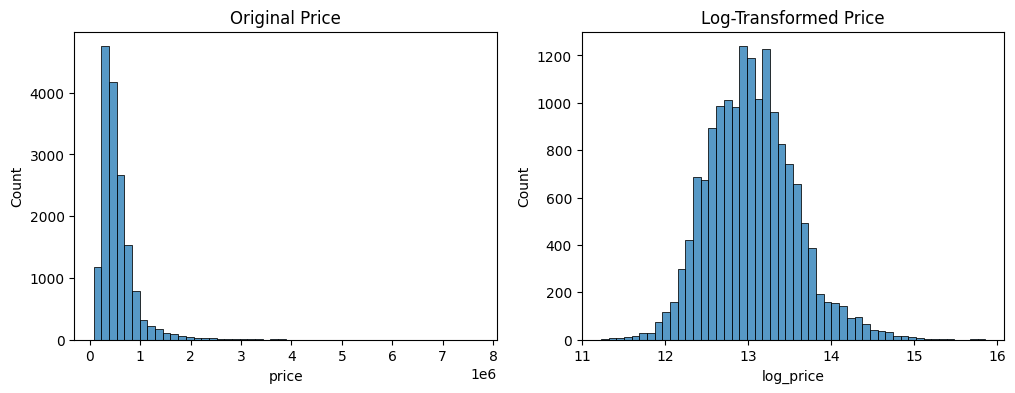

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df["price"], bins=50, ax=axes[0])
axes[0].set_title("Original Price")

sns.histplot(df["log_price"], bins=50, ax=axes[1])
axes[1].set_title("Log-Transformed Price")

plt.show()


In [5]:
df["sqft_living_capped"] = df["sqft_living"].clip(
    upper=df["sqft_living"].quantile(0.99) )
df["house_age"] = 2025 - df["yr_built"]

df["bathroom_per_bedroom"] = df["bathrooms"] / (df["bedrooms"] + 1)


In [6]:
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living_capped",
    "sqft_lot",
    "sqft_living15",
    "sqft_lot15",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "lat",
    "long",
    "house_age",
    "bathroom_per_bedroom"
]


In [7]:
#Missing values
df[features] = df[features].fillna(df[features].median())

In [10]:
# Train / validation split
X = df[features]
y = df[target]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
#Scaling (only affects Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [22]:
# Linear Regression 
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
y_pred = lin_reg.predict(X_val_scaled)

lin_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
lin_r2 = r2_score(y_val, y_pred)

print("Linear Regression RMSE:", lin_rmse)
print("Linear Regression R²:", lin_r2)


Linear Regression RMSE: 0.24906450132003694
Linear Regression R²: 0.7752045803005406


In [24]:
#Radndom Forest Generator 
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred = rf.predict(X_val)

rf_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
rf_r2 = r2_score(y_val, y_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest RMSE: 0.17904586028569777
Random Forest R²: 0.8838304356327961


In [26]:
# XGBoost
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [27]:
y_pred = xgb.predict(X_val)

xgb_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
xgb_r2 = r2_score(y_val, y_pred)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R²:", xgb_r2)


XGBoost RMSE: 0.16700341268795538
XGBoost R²: 0.8989318108627552


Tabular-only insights & Plots

In [28]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE (log-price)": [
        lin_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        lin_r2,
        rf_r2,
        xgb_r2
    ]
})

results


,Model,RMSE (log-price),R2 Score
0,Linear Regression,0.249065,0.775205
1,Random Forest,0.179046,0.883830
2,XGBoost,0.167003,0.898932


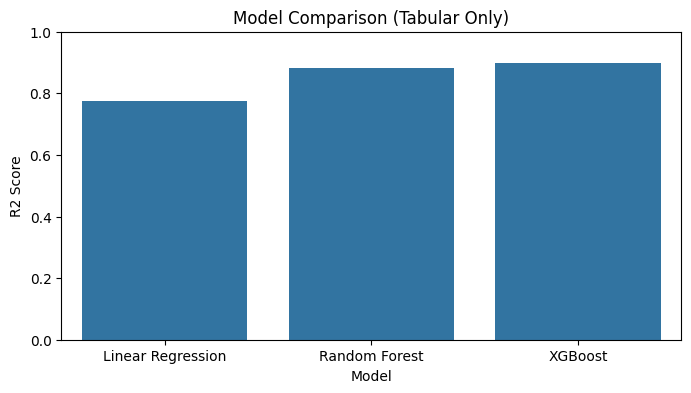

In [29]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x="Model",
    y="R2 Score",
    data=results
)
plt.title("Model Comparison (Tabular Only)")
plt.ylim(0, 1)
plt.show()


In [30]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_df.head(10)


,Feature,Coefficient
11,lat,0.188303
10,grade,0.184154
2,sqft_living_capped,0.135889
13,house_age,0.104105
4,sqft_living15,0.063482
1,bathrooms,0.053393
8,view,0.047893
9,condition,0.038013
6,floors,0.032701
7,waterfront,0.031819


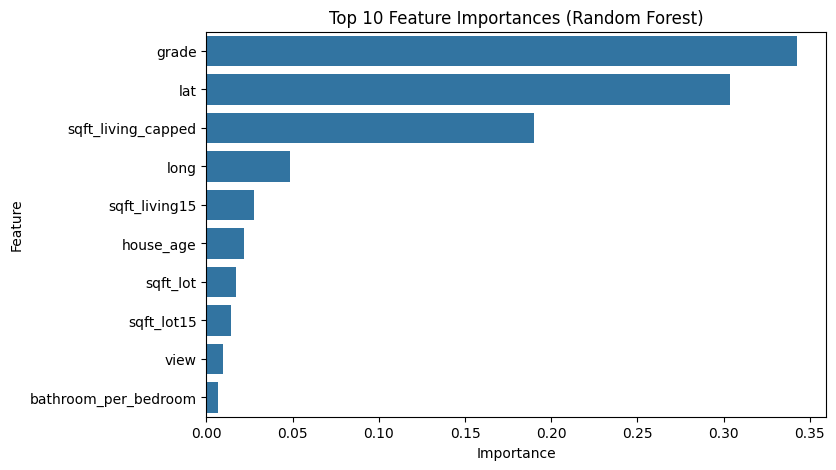

In [31]:
rf_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance.head(10)
)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()


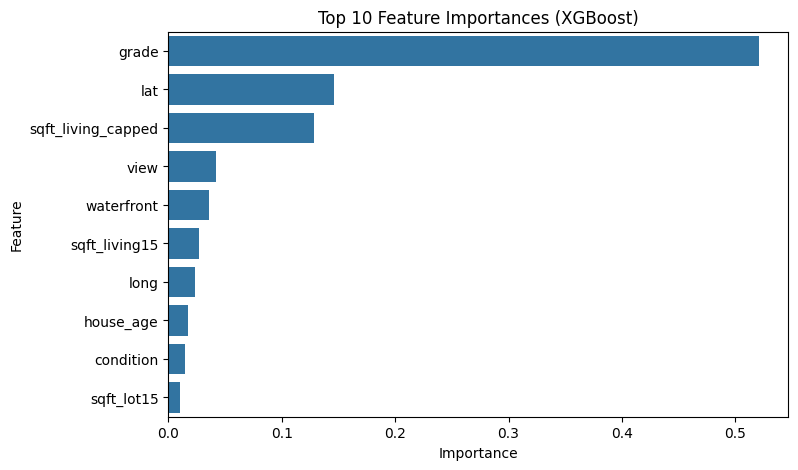

In [32]:
xgb_importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=xgb_importance.head(10)
)
plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()


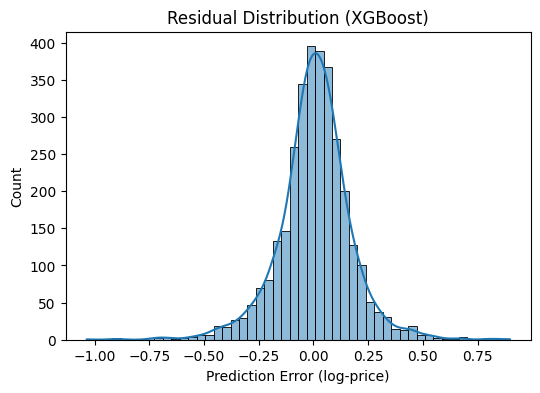

In [33]:
y_val_pred = xgb.predict(X_val)
residuals = y_val - y_val_pred

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution (XGBoost)")
plt.xlabel("Prediction Error (log-price)")
plt.show()


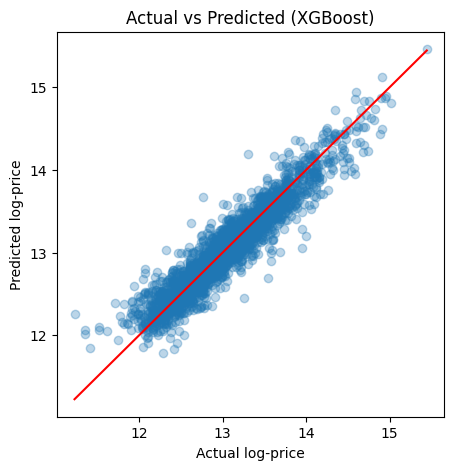

In [34]:
plt.figure(figsize=(5, 5))
plt.scatter(y_val, y_val_pred, alpha=0.3)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         color="red")
plt.xlabel("Actual log-price")
plt.ylabel("Predicted log-price")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()


In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

# ============================================================
# LOAD DATA
# ============================================================

print("=" * 70)
print("LOADING DATA")
print("=" * 70)

train_df = pd.read_csv("../data/raw/train.csv")
test_df  = pd.read_csv("../data/raw/test.csv")

if "id" not in test_df.columns:
    test_df["id"] = test_df.index

test_ids = test_df["id"].values

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# ============================================================
# FEATURE ENGINEERING (EXACTLY AS TABULAR NOTEBOOK)
# ============================================================

def feature_engineering(df):
    df = df.copy()

    # 1. Cap sqft_living at 99th percentile (TRAIN stats for train, TEST stats for test)
    cap = df["sqft_living"].quantile(0.99)
    df["sqft_living_capped"] = df["sqft_living"].clip(upper=cap)

    # 2. House age
    df["house_age"] = 2025 - df["yr_built"]

    # 3. Bathroom per bedroom
    df["bathroom_per_bedroom"] = df["bathrooms"] / (df["bedrooms"] + 1)

    return df

train_df = feature_engineering(train_df)
test_df  = feature_engineering(test_df)

# ============================================================
# FEATURES + TARGET (MATCH NOTEBOOK)
# ============================================================

FEATURES = [
    "bedrooms",
    "bathrooms",
    "sqft_living_capped",
    "sqft_lot",
    "sqft_living15",
    "sqft_lot15",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "lat",
    "long",
    "house_age",
    "bathroom_per_bedroom"
]

X_train = train_df[FEATURES].values.astype(np.float32)
X_test  = test_df[FEATURES].values.astype(np.float32)

# Target: log1p(price)
y_train = np.log1p(train_df["price"].values)

# Safety
X_train = np.nan_to_num(X_train)
X_test  = np.nan_to_num(X_test)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)

# ============================================================
# TRAIN XGBOOST MODEL
# ============================================================

print("\nTraining XGBoost model...")

xgb_model = XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("Training complete")

# ============================================================
# PREDICT ON TEST
# ============================================================

print("\nRunning inference on test set...")

log_preds = xgb_model.predict(X_test)

print("Log-pred stats:")
print("Min :", log_preds.min())
print("Max :", log_preds.max())
print("Mean:", log_preds.mean())

# ============================================================
# CONVERT TO PRICE
# ============================================================

price_preds = np.expm1(log_preds)
price_preds[price_preds < 0] = 0

print("\nPrice stats:")
print("Min   :", price_preds.min())
print("Max   :", price_preds.max())
print("Mean  :", price_preds.mean())
print("Median:", np.median(price_preds))

# ============================================================
# SAVE SUBMISSION
# ============================================================

submission = pd.DataFrame({
    "id": test_ids,
    "price": price_preds
})

submission.to_csv("submission_xgb_tabular.csv", index=False)

print("\n[SUCCESS] submission_xgb_tabular.csv saved")


LOADING DATA
Train shape: (16209, 21)
Test shape : (5404, 20)
X_train shape: (16209, 15)
X_test  shape: (5404, 15)

Training XGBoost model...
Training complete

Running inference on test set...
Log-pred stats:
Min : 11.652154
Max : 15.447202
Mean: 13.0523815

Price stats:
Min   : 114937.67
Max   : 5112512.5
Mean  : 539251.3
Median: 452130.56

[SUCCESS] submission_xgb_tabular.csv saved
